# Эксперимент 4: LightGBM — отдельные модели по горизонтам

**Гипотеза:** единая модель из Эксп. 3 вынуждена находить компромисс между ближними и дальними горизонтами.
Для h=1 ключевой сигнал — `status_3_at_ref`; для h=8 — скользящие средние и маршрутные статистики.
Отдельная модель для каждого горизонта может адаптировать гиперпараметры и автоматически выставить правильные веса признаков.

**Отличия от Эксп. 3:**
- 8 независимых LightGBM-моделей (по одной на h=1..8)
- Убраны `horizon`, `status3_x_horizon`, `pipeline_signal` — они теряют смысл при фиксированном h
- Гиперпараметры настроены по горизонту: h=1 — больше деревьев / меньший lr; h=7–8 — сильнее регуляризация

**Валидация:** rolling-origin, 3 субботних cutoff (Oct 11 / Oct 18 / Oct 25 в 10:30).
Метрика: **WAPE + |Relative Bias|**. Бейзлайн: **0.382**.

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import time

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 5)
sns.set_theme(style='whitegrid', palette='muted')

DATA_DIR = Path('/Users/melikhovartem/Desktop/ИЗИ 200к/Data')

STEP     = pd.Timedelta('30min')
HORIZONS = list(range(1, 9))

# Единые точки обрезки для всех экспериментов
VAL_CUTOFFS = [
    pd.Timestamp('2025-10-11 10:30:00'),
    pd.Timestamp('2025-10-18 10:30:00'),
    pd.Timestamp('2025-10-25 10:30:00'),
]
TEST_CUTOFF = pd.Timestamp('2025-11-01 10:30:00')

SUBSAMPLE_N = 4

# ── Базовые гиперпараметры ─────────────────────────────────────────────────
_BASE = dict(
    objective='regression_l1',
    max_depth=8,
    num_leaves=63,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42,
    verbose=-1,
)

# ── Гиперпараметры по горизонтам ───────────────────────────────────────────
# h=1: сильный конвейерный сигнал → больше деревьев, меньший lr
# h=5-6: средняя регуляризация
# h=7-8: слабый сигнал → агрессивнее регуляризация, меньше деревьев
H_PARAMS = {
    1: dict(**_BASE, n_estimators=1500, learning_rate=0.03, reg_alpha=0.05, reg_lambda=0.5),
    2: dict(**_BASE, n_estimators=1000, learning_rate=0.05, reg_alpha=0.1,  reg_lambda=1.0),
    3: dict(**_BASE, n_estimators=1000, learning_rate=0.05, reg_alpha=0.1,  reg_lambda=1.0),
    4: dict(**_BASE, n_estimators=1000, learning_rate=0.05, reg_alpha=0.1,  reg_lambda=1.0),
    5: dict(**_BASE, n_estimators=1000, learning_rate=0.05, reg_alpha=0.3,  reg_lambda=2.0),
    6: dict(**_BASE, n_estimators=1000, learning_rate=0.05, reg_alpha=0.3,  reg_lambda=2.0),
    7: dict(**_BASE, n_estimators=800,  learning_rate=0.05, reg_alpha=0.5,  reg_lambda=3.0),
    8: dict(**_BASE, n_estimators=800,  learning_rate=0.05, reg_alpha=0.5,  reg_lambda=3.0),
}

print("Конфигурация загружена.")
for h, p in H_PARAMS.items():
    print(f"  h={h}: n_est={p['n_estimators']}, lr={p['learning_rate']}, "
          f"reg_α={p['reg_alpha']}, reg_λ={p['reg_lambda']}")

Конфигурация загружена.
  h=1: n_est=1500, lr=0.03, reg_α=0.05, reg_λ=0.5
  h=2: n_est=1000, lr=0.05, reg_α=0.1, reg_λ=1.0
  h=3: n_est=1000, lr=0.05, reg_α=0.1, reg_λ=1.0
  h=4: n_est=1000, lr=0.05, reg_α=0.1, reg_λ=1.0
  h=5: n_est=1000, lr=0.05, reg_α=0.3, reg_λ=2.0
  h=6: n_est=1000, lr=0.05, reg_α=0.3, reg_λ=2.0
  h=7: n_est=800, lr=0.05, reg_α=0.5, reg_λ=3.0
  h=8: n_est=800, lr=0.05, reg_α=0.5, reg_λ=3.0


In [2]:
train = pd.read_parquet(DATA_DIR / 'train_solo_track.parquet')
test  = pd.read_parquet(DATA_DIR / 'test_solo_track.parquet')

train['timestamp'] = pd.to_datetime(train['timestamp'])
test['timestamp']  = pd.to_datetime(test['timestamp'])

train = train.sort_values(['route_id', 'timestamp']).reset_index(drop=True)
test  = test.sort_values(['route_id', 'timestamp']).reset_index(drop=True)

print(f"Train: {train.shape}  [{train.timestamp.min()} … {train.timestamp.max()}]")
print(f"Test:  {test.shape}   [{test.timestamp.min()} … {test.timestamp.max()}]")

Train: (4630000, 9)  [2025-07-28 00:00:00 … 2025-11-01 10:30:00]
Test:  (8000, 3)   [2025-11-01 11:00:00 … 2025-11-01 14:30:00]


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# Метрики — ЕДИНЫЕ ДЛЯ ВСЕХ ЭКСПЕРИМЕНТОВ
# ══════════════════════════════════════════════════════════════════════════════

def wape(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    return float(np.sum(np.abs(y_true - y_pred)) / np.sum(y_true))

def relative_bias(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    return float((np.sum(y_pred) - np.sum(y_true)) / np.sum(y_true))

def combined_metric(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return wape(y_true, y_pred) + abs(relative_bias(y_true, y_pred))

BASELINE = 0.382
print(f"Метрики определены. Бейзлайн: {BASELINE}")

Метрики определены. Бейзлайн: 0.382


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# Feature Engineering (те же функции, что в Эксп. 3)
# ══════════════════════════════════════════════════════════════════════════════

def compute_route_stats(data: pd.DataFrame) -> pd.DataFrame:
    stats = (
        data.groupby('route_id')['target_1h']
        .agg(
            route_mean='mean',
            route_median='median',
            route_std='std',
            route_q25=lambda x: x.quantile(0.25),
            route_q75=lambda x: x.quantile(0.75),
            route_zero_frac=lambda x: (x == 0).mean(),
        )
        .reset_index()
    )
    stats['route_cv'] = stats['route_std'] / (stats['route_mean'] + 1.0)
    return stats


def compute_ref_features(data: pd.DataFrame, route_stats: pd.DataFrame) -> pd.DataFrame:
    """Вычислить признаки для каждой строки (route_id, timestamp). Без утечки данных."""
    data = data.sort_values(['route_id', 'timestamp']).copy()

    for lag in [1, 2, 3, 4, 6, 12, 24, 48, 96, 336]:
        data[f'target_lag_{lag}'] = data.groupby('route_id')['target_1h'].shift(lag)

    for window, name in [(4,'2h'), (12,'6h'), (24,'12h'), (48,'24h'), (336,'7d')]:
        data[f'target_roll_mean_{name}'] = data.groupby('route_id')['target_1h'].transform(
            lambda x, w=window: x.shift(1).rolling(w, min_periods=1).mean()
        )

    for window, name in [(12,'6h'), (48,'24h')]:
        data[f'target_roll_std_{name}'] = data.groupby('route_id')['target_1h'].transform(
            lambda x, w=window: x.shift(1).rolling(w, min_periods=2).std()
        )

    data['target_ewm_span4'] = data.groupby('route_id')['target_1h'].transform(
        lambda x: x.shift(1).ewm(span=4, min_periods=1).mean()
    )

    data['target_diff_1']  = data.groupby('route_id')['target_1h'].diff(1)
    data['target_diff_48'] = data.groupby('route_id')['target_1h'].diff(48)

    for s in ['status_1', 'status_2', 'status_3', 'status_4', 'status_5']:
        data[f'{s}_at_ref'] = data[s]

    for lag in [1, 2, 3, 4]:
        data[f'status_3_lag_{lag}'] = data.groupby('route_id')['status_3'].shift(lag)

    for s in ['status_1', 'status_2', 'status_3']:
        data[f'{s}_roll_mean_2h'] = data.groupby('route_id')[s].transform(
            lambda x: x.shift(1).rolling(4, min_periods=1).mean()
        )

    for s in ['status_4', 'status_5']:
        data[f'{s}_roll_mean_24h'] = data.groupby('route_id')[s].transform(
            lambda x: x.shift(1).rolling(48, min_periods=1).mean()
        )

    data['ref_hour'] = data['timestamp'].dt.hour
    data['ref_dow']  = data['timestamp'].dt.dayofweek
    data = data.merge(route_stats, on='route_id', how='left')
    return data


def _add_tgt_time_features(df: pd.DataFrame, h: int) -> pd.DataFrame:
    """Добавить временные признаки целевого момента для горизонта h."""
    df = df.copy()
    df['tgt_ts']  = df['timestamp'] + h * STEP
    tgt_hour = df['tgt_ts'].dt.hour + df['tgt_ts'].dt.minute / 60
    tgt_dow  = df['tgt_ts'].dt.dayofweek
    df['tgt_hour_float'] = tgt_hour
    df['tgt_dow']        = tgt_dow
    df['tgt_hour_sin']   = np.sin(2 * np.pi * tgt_hour / 24)
    df['tgt_hour_cos']   = np.cos(2 * np.pi * tgt_hour / 24)
    df['tgt_dow_sin']    = np.sin(2 * np.pi * tgt_dow / 7)
    df['tgt_dow_cos']    = np.cos(2 * np.pi * tgt_dow / 7)
    return df


_TGT_COLS = ['route_id', 'timestamp', 'target_1h']

def build_train_matrix_h(
    feat_df: pd.DataFrame,
    train_full: pd.DataFrame,
    h: int,
    subsample_n: int = 4,
) -> pd.DataFrame:
    """Обучающая матрица для одного горизонта h."""
    feat_df = feat_df.sort_values(['route_id', 'timestamp']).copy()
    feat_df['_rn'] = feat_df.groupby('route_id').cumcount()
    feat_sub = feat_df[feat_df['_rn'] % subsample_n == 0].drop('_rn', axis=1).copy()

    feat_sub = _add_tgt_time_features(feat_sub, h)

    tgt_lookup = (
        train_full[_TGT_COLS]
        .rename(columns={'timestamp': 'tgt_ts', 'target_1h': 'target'})
    )
    feat_sub = feat_sub.merge(tgt_lookup, on=['route_id', 'tgt_ts'], how='left')
    feat_sub = feat_sub.dropna(subset=['target'])
    return feat_sub


def build_inference_h(feat_df: pd.DataFrame, cutoff: pd.Timestamp, h: int) -> pd.DataFrame:
    """Инференс-матрица для одного горизонта h в момент cutoff."""
    cutoff_df = feat_df[feat_df['timestamp'] == cutoff].copy()
    assert len(cutoff_df) == 1000, f"h={h}: ожидается 1000 маршрутов, получено {len(cutoff_df)}"
    cutoff_df = _add_tgt_time_features(cutoff_df, h)
    return cutoff_df.sort_values('route_id').reset_index(drop=True)


print("Функции feature engineering определены.")

Функции feature engineering определены.


In [5]:
# Список признаков: те же, что в Эксп. 3, но БЕЗ horizon-зависимых
# (убраны 'horizon', 'status3_x_horizon', 'pipeline_signal' —
#  при фиксированном h они избыточны: модель сама выбирает нужный status)
FEATURE_COLS = [
    # Маршрут (категориальный)
    'route_id',
    # Маршрутные статистики
    'route_mean', 'route_median', 'route_std',
    'route_q25', 'route_q75', 'route_zero_frac', 'route_cv',
    # Временные признаки целевого момента
    'tgt_hour_float', 'tgt_dow',
    'tgt_hour_sin', 'tgt_hour_cos', 'tgt_dow_sin', 'tgt_dow_cos',
    # Временные признаки точки отсчёта
    'ref_hour', 'ref_dow',
    # Лаги таргета
    'target_lag_1', 'target_lag_2', 'target_lag_3', 'target_lag_4',
    'target_lag_6', 'target_lag_12', 'target_lag_24',
    'target_lag_48', 'target_lag_96', 'target_lag_336',
    # Rolling mean таргета
    'target_roll_mean_2h', 'target_roll_mean_6h', 'target_roll_mean_12h',
    'target_roll_mean_24h', 'target_roll_mean_7d',
    # Rolling std таргета
    'target_roll_std_6h', 'target_roll_std_24h',
    # EWM + разности
    'target_ewm_span4', 'target_diff_1', 'target_diff_48',
    # Status-фичи (все присутствуют: модель сама выберет вес по горизонту)
    'status_1_at_ref', 'status_2_at_ref', 'status_3_at_ref',
    'status_4_at_ref', 'status_5_at_ref',
    'status_3_lag_1', 'status_3_lag_2', 'status_3_lag_3', 'status_3_lag_4',
    'status_1_roll_mean_2h', 'status_2_roll_mean_2h', 'status_3_roll_mean_2h',
    'status_4_roll_mean_24h', 'status_5_roll_mean_24h',
]

CAT_FEATURES = ['route_id']

print(f"Всего признаков: {len(FEATURE_COLS)}")
print(f"(В Эксп. 3 было 48 — сейчас {len(FEATURE_COLS)}: убраны horizon/status3_x_horizon/pipeline_signal)")

Всего признаков: 50
(В Эксп. 3 было 48 — сейчас 50: убраны horizon/status3_x_horizon/pipeline_signal)


## Кросс-валидация (rolling-origin по субботам)

Схема идентична Эксп. 3. Для каждого фолда:
1. Вычисляем общие признаки `feat_df` один раз
2. Для каждого h=1..8: строим матрицу, обучаем отдельную модель, делаем прогноз на cutoff
3. Агрегируем 8000 прогнозов (1000 маршрутов × 8 горизонтов), калибруем, считаем метрику

In [6]:
fold_results    = []
all_horizon_acc = {h: {'WAPE': [], 'Total': []} for h in HORIZONS}
last_models     = {}   # h -> model (из последнего фолда, для feature importance)

for fold_idx, cutoff in enumerate(VAL_CUTOFFS):
    t0 = time.time()
    print(f"\n{'='*60}")
    print(f"Фолд {fold_idx+1}/{len(VAL_CUTOFFS)}: cutoff = {cutoff}")

    # ── Общие признаки (вычисляются один раз на фолд) ──────────────────────
    train_cut   = train[train['timestamp'] <= cutoff].copy()
    route_stats = compute_route_stats(train_cut)
    print(f"  Вычисляю ref_features ({len(train_cut):,} строк) ...", end=' ', flush=True)
    feat_df = compute_ref_features(train_cut, route_stats)
    print("готово")

    # ── Обучение 8 моделей + прогноз ───────────────────────────────────────
    h_preds   = {}   # h -> (route_ids sorted, raw_preds)
    h_actuals = {}   # h -> actual y values (sorted by route_id)

    for h in HORIZONS:
        # Обучающая матрица для этого горизонта
        tr_h = build_train_matrix_h(feat_df, train, h, subsample_n=SUBSAMPLE_N)
        model_h = lgb.LGBMRegressor(**H_PARAMS[h])
        model_h.fit(tr_h[FEATURE_COLS], tr_h['target'], categorical_feature=CAT_FEATURES)

        # Инференс
        inf_h   = build_inference_h(feat_df, cutoff, h)   # уже sorted by route_id
        pred_h  = np.maximum(model_h.predict(inf_h[FEATURE_COLS]), 0)
        h_preds[h] = (inf_h['route_id'].values, pred_h)

        # Реальные значения
        tgt_ts = cutoff + h * STEP
        act_h  = (
            train[train['timestamp'] == tgt_ts][['route_id', 'target_1h']]
            .sort_values('route_id')
            .reset_index(drop=True)
        )
        h_actuals[h] = act_h['target_1h'].values

        if fold_idx == len(VAL_CUTOFFS) - 1:
            last_models[h] = model_h

        print(f"  h={h}: обучено ({len(tr_h):,} строк)", end='\r')

    print()

    # ── Агрегация прогнозов и реальных значений ────────────────────────────
    preds_all   = np.concatenate([h_preds[h][1]  for h in HORIZONS])
    actuals_all = np.concatenate([h_actuals[h]   for h in HORIZONS])

    # ── Калибровка (обнуляет Relative Bias) ────────────────────────────────
    ratio     = actuals_all.sum() / preds_all.sum()
    preds_cal = preds_all * ratio

    # ── Метрики фолда ──────────────────────────────────────────────────────
    wape_v  = wape(actuals_all, preds_cal)
    rbias_v = relative_bias(actuals_all, preds_cal)
    total_v = wape_v + abs(rbias_v)

    # ── Метрики по горизонтам ──────────────────────────────────────────────
    horizon_metrics = []
    offset = 0
    for h in HORIZONS:
        n    = len(h_actuals[h])
        y_h  = actuals_all[offset:offset+n]
        p_h  = preds_cal[offset:offset+n]
        w_h  = wape(y_h, p_h)
        b_h  = relative_bias(y_h, p_h)
        t_h  = w_h + abs(b_h)
        horizon_metrics.append({'horizon': h, 'WAPE': w_h, 'RBias': b_h, 'Total': t_h})
        all_horizon_acc[h]['WAPE'].append(w_h)
        all_horizon_acc[h]['Total'].append(t_h)
        offset += n

    elapsed = time.time() - t0
    print(f"  WAPE={wape_v:.4f}  |RBias|={abs(rbias_v):.4f}  Total={total_v:.4f}")
    print(f"  ratio={ratio:.4f}  время={elapsed:.1f}с")

    fold_results.append({
        'fold': fold_idx + 1,
        'cutoff': str(cutoff.date()),
        'WAPE': wape_v, 'RBias': rbias_v, 'Total': total_v,
        'ratio': ratio,
        'horizon_metrics': horizon_metrics,
        'elapsed': elapsed,
    })

print(f"\n{'='*60}")
print("Валидация завершена.")


Фолд 1/3: cutoff = 2025-10-11 10:30:00
  Вычисляю ref_features (3,622,000 строк) ... готово
  h=8: обучено (906,000 строк)
  WAPE=0.3357  |RBias|=0.0000  Total=0.3357
  ratio=1.0303  время=249.9с

Фолд 2/3: cutoff = 2025-10-18 10:30:00
  Вычисляю ref_features (3,958,000 строк) ... готово
  h=8: обучено (990,000 строк)
  WAPE=0.3238  |RBias|=0.0000  Total=0.3238
  ratio=1.0618  время=333.9с

Фолд 3/3: cutoff = 2025-10-25 10:30:00
  Вычисляю ref_features (4,294,000 строк) ... готово
  h=8: обучено (1,074,000 строк)
  WAPE=0.3211  |RBias|=0.0000  Total=0.3211
  ratio=1.0448  время=368.0с

Валидация завершена.


In [7]:
# Сводная таблица фолдов
rows = [
    {'Фолд': r['fold'], 'Cutoff': r['cutoff'],
     'WAPE': r['WAPE'], '|RBias|': abs(r['RBias']),
     'Total': r['Total'], 'Ratio': r['ratio'], 'Время, с': round(r['elapsed'])}
    for r in fold_results
]
res_df = pd.DataFrame(rows)
mean_row = res_df[['WAPE','|RBias|','Total','Ratio','Время, с']].mean().to_dict()
mean_row.update({'Фолд': 'Среднее', 'Cutoff': ''})
res_df = pd.concat([res_df, pd.DataFrame([mean_row])], ignore_index=True)

print("Результаты кросс-валидации:")
print(res_df.to_string(index=False, float_format='{:.4f}'.format))

mean_total = float(res_df.loc[res_df['Фолд'] == 'Среднее', 'Total'].values[0])
print(f"\nБейзлайн: {BASELINE:.4f}  →  Эксп 4: {mean_total:.4f}  (Δ = {mean_total-BASELINE:+.4f})")

Результаты кросс-валидации:
   Фолд     Cutoff   WAPE  |RBias|  Total  Ratio  Время, с
      1 2025-10-11 0.3357   0.0000 0.3357 1.0303  250.0000
      2 2025-10-18 0.3238   0.0000 0.3238 1.0618  334.0000
      3 2025-10-25 0.3211   0.0000 0.3211 1.0448  368.0000
Среднее            0.3269   0.0000 0.3269 1.0457  317.3333

Бейзлайн: 0.3820  →  Эксп 4: 0.3269  (Δ = -0.0551)


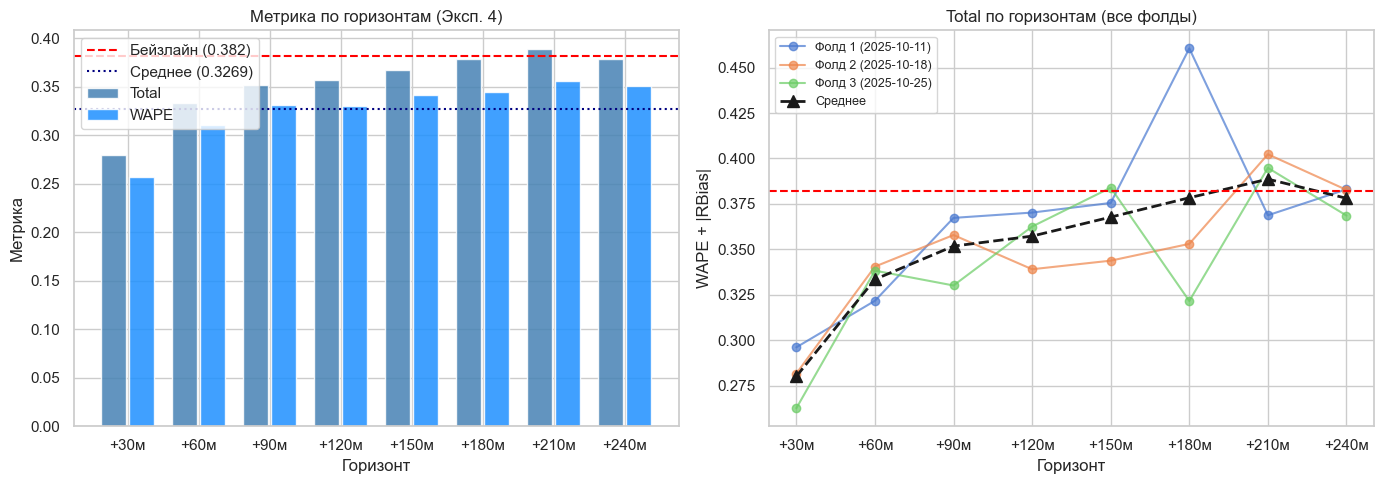

     Горизонт   WAPE  Total
 h=1 (+30мин) 0.2566 0.2801
 h=2 (+60мин) 0.3101 0.3335
 h=3 (+90мин) 0.3308 0.3518
h=4 (+120мин) 0.3297 0.3573
h=5 (+150мин) 0.3415 0.3677
h=6 (+180мин) 0.3445 0.3784
h=7 (+210мин) 0.3556 0.3886
h=8 (+240мин) 0.3511 0.3781


In [8]:
# Метрика по горизонтам
h_wape  = [np.mean(all_horizon_acc[h]['WAPE'])  for h in HORIZONS]
h_total = [np.mean(all_horizon_acc[h]['Total']) for h in HORIZONS]
h_labels = [f'+{h*30}м' for h in HORIZONS]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
x = np.arange(len(HORIZONS))
ax.bar(x - 0.2, h_total, 0.35, label='Total', color='steelblue', alpha=0.85)
ax.bar(x + 0.2, h_wape,  0.35, label='WAPE',  color='dodgerblue', alpha=0.85)
ax.axhline(BASELINE, color='red', linestyle='--', linewidth=1.5, label=f'Бейзлайн ({BASELINE})')
ax.axhline(mean_total, color='navy', linestyle=':', linewidth=1.5, label=f'Среднее ({mean_total:.4f})')
ax.set_xticks(x); ax.set_xticklabels(h_labels)
ax.set_title('Метрика по горизонтам (Эксп. 4)', fontsize=12)
ax.set_ylabel('Метрика'); ax.set_xlabel('Горизонт'); ax.legend()

ax = axes[1]
for r in fold_results:
    totals = [hm['Total'] for hm in r['horizon_metrics']]
    ax.plot(HORIZONS, totals, 'o-', alpha=0.7, label=f"Фолд {r['fold']} ({r['cutoff']})")
ax.plot(HORIZONS, h_total, 'k^--', linewidth=2, markersize=8, label='Среднее')
ax.axhline(BASELINE, color='red', linestyle='--', linewidth=1.5)
ax.set_xticks(HORIZONS); ax.set_xticklabels(h_labels)
ax.set_title('Total по горизонтам (все фолды)', fontsize=12)
ax.set_ylabel('WAPE + |RBias|'); ax.set_xlabel('Горизонт'); ax.legend(fontsize=9)

plt.tight_layout(); plt.show()

horizon_df = pd.DataFrame({
    'Горизонт': [f'h={h} (+{h*30}мин)' for h in HORIZONS],
    'WAPE':  [f'{v:.4f}' for v in h_wape],
    'Total': [f'{v:.4f}' for v in h_total],
})
print(horizon_df.to_string(index=False))

In [ ]:
# Feature importance: сравниваем h=1 (ближний) vs h=8 (дальний)
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, h, color in zip(axes, [1, 8], ['tomato', 'steelblue']):
    fi = pd.DataFrame({
        'feature':    FEATURE_COLS,
        'importance': last_models[h].feature_importances_,
    }).sort_values('importance', ascending=False).head(20)

    ax.barh(fi['feature'][::-1], fi['importance'][::-1], color=color, alpha=0.85)
    ax.set_title(f'Feature importance — модель h={h} (+{h*30} мин)', fontsize=12)
    ax.set_xlabel('Importance (split gain)')
    plt.setp(ax.get_yticklabels(), fontsize=9)

plt.suptitle('Сравнение важности признаков: ближний (h=1) vs дальний (h=8) горизонт',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Таблица: топ-10 для каждого горизонта
print("Топ-5 признаков для каждой модели:")
header = f"{'h':>3}  {'#1':^25} {'#2':^25} {'#3':^25}"
print(header)
print('-' * len(header))
for h in HORIZONS:
    fi_h = pd.DataFrame({
        'feature': FEATURE_COLS,
        'imp':     last_models[h].feature_importances_,
    }).sort_values('imp', ascending=False)
    top3 = fi_h['feature'].head(3).tolist()
    print(f"  {h}  {top3[0]:^25} {top3[1]:^25} {top3[2]:^25}")

## Финальная модель + Тестовые прогнозы

Обучаем 8 финальных моделей на полном train. Калибруем через среднее `ratio` по фолдам.

In [9]:
print("Обучаю финальные модели на полном train ...")
t0 = time.time()

route_stats_full = compute_route_stats(train)
print("  Вычисляю ref_features (полный train) ...", end=' ', flush=True)
feat_full = compute_ref_features(train, route_stats_full)
print("готово")

final_models = {}

for h in HORIZONS:
    tr_h = build_train_matrix_h(feat_full, train, h, subsample_n=SUBSAMPLE_N)
    m = lgb.LGBMRegressor(**H_PARAMS[h])
    m.fit(tr_h[FEATURE_COLS], tr_h['target'], categorical_feature=CAT_FEATURES)
    final_models[h] = m
    print(f"  h={h}: обучено ({len(tr_h):,} строк)", end='\r')

print(f"\nВсе 8 моделей обучены ({time.time()-t0:.1f}с)")

# ── Тестовые прогнозы ──────────────────────────────────────────────────────
mean_ratio = np.mean([r['ratio'] for r in fold_results])
print(f"\nКалибровочный коэф (среднее по фолдам): {mean_ratio:.4f}")

sub_rows = []
for h in HORIZONS:
    inf_h = build_inference_h(feat_full, TEST_CUTOFF, h)
    pred_h = np.maximum(final_models[h].predict(inf_h[FEATURE_COLS]), 0) * mean_ratio
    tmp = inf_h[['route_id']].copy()
    tmp['timestamp'] = TEST_CUTOFF + h * STEP
    tmp['y_pred'] = pred_h   # float, без округления
    sub_rows.append(tmp)

sub = pd.concat(sub_rows, ignore_index=True)
test_ids = test[['id', 'route_id', 'timestamp']].copy()
sub = sub.merge(test_ids, on=['route_id', 'timestamp'], how='left')
sub = sub[['id', 'y_pred']].sort_values('id').reset_index(drop=True)

assert len(sub) == len(test)
assert sub['id'].notna().all()

out_path = '/Users/melikhovartem/Desktop/ИЗИ 200к/submission_exp04.csv'
sub.to_csv(out_path, index=False)
print(f"Submission сохранён: {out_path}")
print(f"Прогнозы: min={sub['y_pred'].min():.0f}  max={sub['y_pred'].max():.0f}  mean={sub['y_pred'].mean():.0f}")
print(sub.head(8).to_string(index=False))

Обучаю финальные модели на полном train ...
  Вычисляю ref_features (полный train) ... готово
  h=8: обучено (1,156,000 строк)
Все 8 моделей обучены (365.2с)

Калибровочный коэф (среднее по фолдам): 1.0457
Submission сохранён: /Users/melikhovartem/Desktop/ИЗИ 200к/submission_exp04.csv
Прогнозы: min=0  max=2077311  mean=274850
 id        y_pred
  0  86838.661752
  1 128851.166998
  2 141702.711028
  3 165696.759408
  4 176648.175685
  5 168896.209154
  6 123762.086888
  7 142345.001142


## Итоговые метрики (для сравнения экспериментов)

In [ ]:
mean_wape  = np.mean([r['WAPE']       for r in fold_results])
mean_rbias = np.mean([abs(r['RBias']) for r in fold_results])
mean_total = np.mean([r['Total']      for r in fold_results])

print("=" * 65)
print("ИТОГОВЫЕ МЕТРИКИ — ЭКСПЕРИМЕНТ 4")
print("8 отдельных LightGBM-моделей (по одной на горизонт)")
print("=" * 65)
print(f"\nВалидация: rolling-origin, 3 субботних фолда\n")

summary_df = pd.DataFrame({
    'Метрика':              ['WAPE', '|Relative Bias|', 'Total (WAPE+|RBias|)'],
    'Среднее по 3 фолдам': [f'{mean_wape:.4f}', f'{mean_rbias:.4f}', f'{mean_total:.4f}'],
})
print(summary_df.to_string(index=False))

print(f"\n{'─'*65}")
print("Сравнение экспериментов (заполните Эксп. 3 после его запуска):")
comparison = pd.DataFrame([
    {'Эксперимент': 'Exp 0: среднее по маршруту',             'Total': 0.382},
    {'Эксперимент': 'Exp 3: LightGBM + conveyor (1 модель)',  'Total': float('nan')},  # заполнить после запуска
    {'Эксперимент': '▶ Exp 4: LightGBM × 8 моделей',         'Total': mean_total},
])
print(comparison.to_string(index=False, float_format='{:.4f}'.format))

# ── Итоговый график ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
fold_labels  = [r['cutoff'] for r in fold_results]
fold_totals  = [r['Total']  for r in fold_results]
bars = ax.bar(fold_labels, fold_totals, color='steelblue', alpha=0.85, width=0.5)
ax.axhline(mean_total, color='navy', linewidth=2, label=f'Среднее = {mean_total:.4f}')
ax.axhline(BASELINE,   color='red',  linewidth=1.5, linestyle='--', label=f'Baseline = {BASELINE}')
for bar, v in zip(bars, fold_totals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.002, f'{v:.4f}',
            ha='center', va='bottom', fontsize=10)
ax.set_title('Total metric по фолдам', fontsize=12)
ax.set_ylabel('WAPE + |RBias|'); ax.legend()
ax.set_ylim(0, max(fold_totals) * 1.15)

ax = axes[1]
ax.plot(HORIZONS, h_total, 'o-', color='steelblue', linewidth=2, markersize=7, label='Total (Exp 4)')
ax.plot(HORIZONS, h_wape,  's--', color='dodgerblue', linewidth=1.5, markersize=6, label='WAPE (Exp 4)')
ax.axhline(BASELINE,   color='red',  linestyle='--', linewidth=1.5, label=f'Baseline = {BASELINE}')
ax.axhline(mean_total, color='navy', linestyle=':', linewidth=1.5, label=f'Ср. Total = {mean_total:.4f}')
ax.set_xticks(HORIZONS); ax.set_xticklabels([f'+{h*30}м' for h in HORIZONS])
ax.set_title('Total по горизонтам прогноза', fontsize=12)
ax.set_ylabel('Метрика'); ax.set_xlabel('Горизонт'); ax.legend(fontsize=9)

plt.suptitle('Эксперимент 4: LightGBM — 8 отдельных моделей', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print(f"\n{'='*65}")
print(f"  ИТОГ: Total = {mean_total:.4f}  (бейзлайн: {BASELINE}  Δ={mean_total-BASELINE:+.4f})")
print(f"{'='*65}")